In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [23]:
# note these are colors from the matplotlib xkcd colormaps, unless otherwise specified
blues = [
    ('light', '#95D0FC'),
    ('medium', '#0343DF'),
    ('dark', "#333465"),
]

reds = [
    ('light', '#FF474C'),
    ('medium', '#E50000'),
    ('dark', "#840000"),
]

greys = [
    ('light', '#D8DCD6'),
    ('medium', '#929591'),
    ('dark', "#363737"),
]

purples = [
    ('light', '#c27ef6'), # original color #BF77F6, lightened 5%
    ('medium', '#8921aa'), # original color #7E1E9C, lightened 5%
    ('dark', "#460852"), # original color #35063e, lightened 5%
]

greens = [
    ('light', '#96F97B'),
    ('medium', '#15B01A'),
    ('dark', "#033500"),
]

yellows = [
    ('light', '#f7f700'), # actually medium yellow, darkened by 10%
    ('medium', '#D5B60A'), # actually dark yellow
    ('dark', "#957f07"), # origina color #D5B60A, darkened 30%
]

oranges = [
    ('light', '#FDAA48'),
    ('medium', '#F97306'),
    ('dark', "#C65102"),
]

In [48]:
inst_dict = {'MUSE':[465*1e-6,930*1e-6,blues[1][1],0.24], 'ERIS':[1*1e-3,5*1e-3,blues[1][1],0.24], 'KMOS':[0.8*1e-3,2.5*1e-3,blues[1][1],0.18], 'NIRSpec':[0.6*1e-3,5.3*1e-3,oranges[1][1],0.12],
        'ALMA':[0.3,3.6,reds[1][1],0.24], 'band_NS1':[0.81*1e-3,1.27*1e-3,oranges[0][1],0.11], 'band_NS2':[0.97*1e-3,1.89*1e-3,oranges[1][1],0.10],
        'band_NS3':[1.66*1e-3,3.17*1e-3,oranges[2][1],0.11], 'band_NS4':[2.87*1e-3,5.27*1e-3,oranges[0][1],0.10], 'band_A10':[0.3,0.4,reds[0][1],0.23], 'band_A9':[0.4,0.5,reds[1][1],0.23],
        'band_A8':[0.6,0.8,reds[2][1],0.23], 'band_A7':[0.8,1.1,reds[0][1],0.23], 'band_A6':[1.1,1.4,reds[1][1],0.23], 'band_A5':[1.4,1.8,reds[2][1],0.23], 'band_A4':[1.8,2.4,reds[0][1],0.23],
        'band_A3':[2.6,3.6,reds[1][1],0.23]}


line_dict = {'Ha':[656*1e-6,reds[1][1],0.52], 'Hb':[486*1e-6,reds[1][1],0.55], 'CO(1-0)':[2.6,purples[1][1],0.44], 'CO(2-1)':[1.3,purples[1][1],0.47], 'CO(3-2)':[0.87,purples[1][1],0.5],
        'CO(4-3)':[0.65,purples[1][1],0.41], 'CO(5-4)':[0.52,purples[1][1],0.44], 'CO(6-5)':[0.43,purples[1][1],0.47], 'CO(7-6)':[0.37,purples[1][1],0.5], '[CI](1-0)':[609*1e-3,blues[1][1],0.57],
        '[CI](2-1)':[370*1e-3,blues[1][1],0.6], '[CII]':[158*1e-3,greens[1][1],0.55]}

In [49]:
instruments = {'MUSE','ERIS','KMOS','NIRSpec','ALMA'} # options are 'MUSE', 'ERIS', 'KMOS', 'NIRSpec', 'ALMA'
lines = {'Ha','Hb','CO','[CI]','[CII]'} # options are 'Ha', 'Hb', 'CO', '[CI]', '[CII]'
bands = {'all'}
z=0

if 'NIRSpec' in instruments:
    instruments.update(['band_NS1', 'band_NS2', 'band_NS3', 'band_NS4'])
if 'ALMA' in instruments:
    instruments.update(['band_A10', 'band_A9', 'band_A8', 'band_A7', 'band_A6', 'band_A5', 'band_A4', 'band_A3'])



if '[CI]' in lines:
    lines.update(['[CI](1-0)', '[CI](2-1)'])
    lines.remove('[CI]')
if 'CO' in lines:
    lines.update(['CO(1-0)', 'CO(2-1)', 'CO(3-2)', 'CO(4-3)', 'CO(5-4)', 'CO(6-5)', 'CO(7-6)'])
    lines.remove('CO')


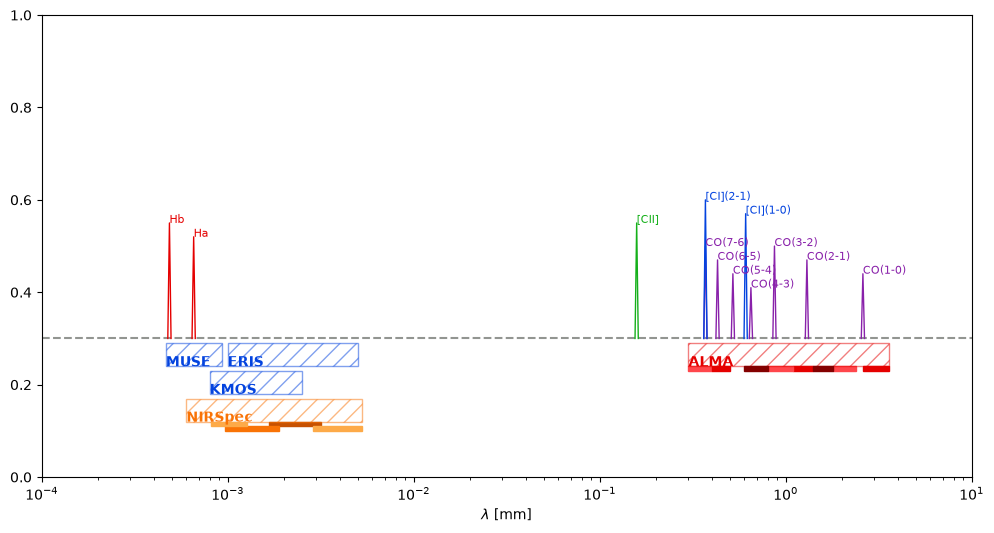

In [50]:
xmin_mm=1e-4
xmax_mm=1e1

fig,ax = plt.subplots(figsize=(12,6))

ax.axhline(y=0.3,color=greys[1][1],linestyle='--')

for inst in instruments:
    vals = inst_dict[inst]
    if inst.startswith('band'):
        rect = patches.Rectangle((vals[0],vals[3]), vals[1]-vals[0], 0.01, edgecolor=vals[2], facecolor=vals[2])
        ax.add_patch(rect)
    else:
        #                          lmin    pos          lwidth      height
        rect = patches.Rectangle((vals[0],vals[3]), vals[1]-vals[0], 0.05, edgecolor=vals[2], facecolor='none', hatch='//',alpha=0.5)
        ax.add_patch(rect)
        ax.text(vals[0],vals[3],inst,color=vals[2],weight='bold')

for line in lines:
    vals = line_dict[line]
    wav = vals[0]*(1+z)
    if wav>xmin_mm and wav<xmax_mm:
        #                       l
        ax.plot(np.array([0.98,1,1.02])*wav, [0.3,vals[2],0.3], c=vals[1],linewidth=1)
        ax.text(wav,vals[2],line,color=vals[1],size=8)

ax.set_xscale('log')
ax.set_xlim((xmin_mm,xmax_mm))
ax.set_ylim(0,1)
ax.set_xlabel(r'$\lambda$ [mm]')

plt.show()